#### Инициализация Keras

In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch

print(keras.__version__)

random_seed = 42
device = "cpu"
keras.utils.set_random_seed(random_seed)

if torch.backends.mps.is_available():
    device = "mps"
    print("Ускорение GPU Apple Metal активно")
elif torch.cuda.is_available():
    device = "cuda"
    print("Ускорение GPU NVIDIA CUDA активно")
else:
    try:
        import torch_directml

        device = torch_directml.device()
        print("Ускорение GPU AMD DirectML активно")
    except ImportError:
        print("Используется CPU")


3.14.0
Ускорение GPU Apple Metal активно


#### Загрузка набора данных для задачи классификации

В данном примере используется фрагмент набора  данных Cats and Dogs Classification Dataset

В наборе данных два класса (всего 24 998 изображений): кошки (12 499 изображения) и собаки (12 499 изображения)

Ссылка: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset

In [2]:
import os

import kagglehub

path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
path = os.path.join(path, "PetImages")

In [3]:
import os

from PIL import Image
from tqdm import tqdm


def check_and_fix_images(directory: str) -> None:
    image_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                image_paths.append(os.path.join(root, file))

    for img_path in tqdm(image_paths, desc="Fixing images", unit="img"):
        try:
            with Image.open(img_path) as img:
                img.convert("RGB").save(img_path, "JPEG")
        except Exception as e:
            print(f"\nОшибка в файле {img_path}: {e}")


check_and_fix_images(path)

Fixing images: 100%|██████████| 24998/24998 [00:29<00:00, 837.27img/s]


#### Формирование выборок

Формируется две выборки: обучающая и валидационная (80 / 20).

В каждой выборке изображения масштабируются до размера 224 на 224 пиксела с RGB пространством.

Изображения подгружаются с диска в процессе обучения и валидации модели.

In [4]:
import keras

batch_size = 64
target_size = (224, 224)

# Загрузка обучающей выборки
train = keras.utils.image_dataset_from_directory(
    directory=path,
    validation_split=0.2,
    subset="training",
    seed=random_seed,
    image_size=target_size,
    batch_size=batch_size,
    color_mode="rgb",
    label_mode="binary",
    shuffle=True,
)

# Загрузка валидационной выборки
valid = keras.utils.image_dataset_from_directory(
    directory=path,
    validation_split=0.2,
    subset="validation",
    seed=random_seed,
    image_size=target_size,
    batch_size=batch_size,
    color_mode="rgb",
    label_mode="binary",
    shuffle=True,
)

class_names = train.class_names # type: ignore
print(f"Имена классов: {class_names}")

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.
Имена классов: ['Cat', 'Dog']


### Архитектура AlexNet

Модель AlexNet описана в лекции про глубокое обучение

#### Проектирование архитектуры AlexNet

In [5]:
from keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, InputLayer, MaxPooling2D
from keras.models import Sequential

alexnet_model = Sequential()

# Входной слой
alexnet_model.add(InputLayer(shape=(224, 224, 3)))

# Первый скрытый слой
alexnet_model.add(Conv2D(96, kernel_size=(11, 11), strides=(4, 4), activation="relu"))
alexnet_model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
alexnet_model.add(BatchNormalization())

# Второй скрытый слой
alexnet_model.add(Conv2D(256, kernel_size=(5, 5), activation="relu"))
alexnet_model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
alexnet_model.add(BatchNormalization())

# Третий скрытый слой
alexnet_model.add(Conv2D(256, kernel_size=(3, 3), activation="relu"))

# Четвертый скрытый слой
alexnet_model.add(Conv2D(384, kernel_size=(3, 3), activation="relu"))

# Пятый скрытый слой
alexnet_model.add(Conv2D(384, kernel_size=(3, 3), activation="relu"))
alexnet_model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))
alexnet_model.add(BatchNormalization())

# Шестой скрытый слой
alexnet_model.add(Flatten())
alexnet_model.add(Dense(4096, activation="tanh"))
alexnet_model.add(Dropout(0.5))

# Седьмой скрытый слой
alexnet_model.add(Dense(4096, activation="tanh"))
alexnet_model.add(Dropout(0.5))

# Выходной слой
alexnet_model.add(Dense(1, activation="sigmoid"))

alexnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 1, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     1,576,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,817,601 (83.23 MB)

 Trainable params: 21,816,129 (83.22 MB)

 Non-trainable params: 1,472 (5.75 KB)

#### Обучение глубокой модели

In [25]:
alexnet_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

alexnet_model.fit(
    x=train,
    validation_data=valid,
    epochs=100
)
alexnet_model.save("models/alexnet_model.keras")

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 298ms/step - accuracy: 0.5041 - loss: 0.7630 - val_accuracy: 0.4845 - val_loss: 0.7437
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 298ms/step - accuracy: 0.5063 - loss: 0.7587 - val_accuracy: 0.5221 - val_loss: 0.7063
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 304ms/step - accuracy: 0.5041 - loss: 0.7500 - val_accuracy: 0.5247 - val_loss: 0.7318
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 307ms/step - accuracy: 0.5038 - loss: 0.7789 - val_accuracy: 0.5349 - val_loss: 0.7092
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 301ms/step - accuracy: 0.5034 - loss: 0.7709 - val_accuracy: 0.4945 - val_loss: 0.7060
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 300ms/step - accuracy: 0.5097 - loss: 0.7621 - val_accuracy: 0.5001 - val_loss: 0.7162
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 312ms/step - accuracy: 0.5082 - loss: 0.7723 - val_accuracy: 0.5271 - val_loss: 0.6954
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 305ms/step - accuracy: 0.5145 -

#### Оценка качества модели

Качество модели чуть больше 83 %.

In [26]:
alexnet_model = keras.models.load_model("models/alexnet_model.keras")
if alexnet_model is None:
    raise SystemError("Model is not exists")
alexnet_model.evaluate(valid)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8370 - loss: 0.6913


[0.6913187503814697, 0.836967408657074]

#### Пример использования обученной модели

Для примера используются случайные изображения из сети Интернет

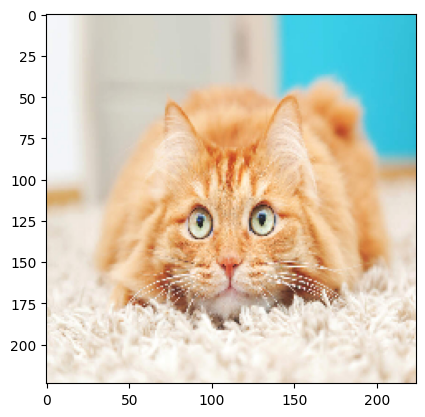

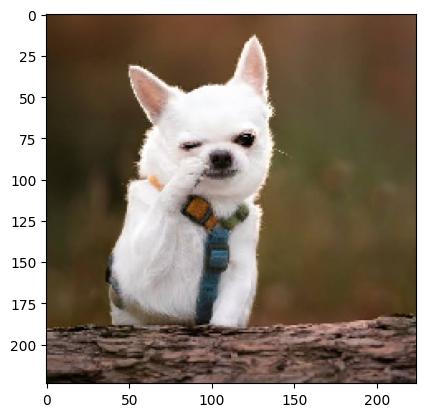

In [27]:
from matplotlib import pyplot as plt

cat = keras.utils.load_img("data/cv/cat.jpg", target_size=(224, 224))
plt.imshow(cat)
plt.show()

dog = keras.utils.load_img("data/cv/dog.jpg", target_size=(224, 224))
plt.imshow(dog)
plt.show()

In [28]:
import numpy as np


def resize(img: Image.Image) -> np.ndarray:
    img_array = keras.utils.img_to_array(img)
    return np.expand_dims(img_array, axis=0)

resized_cat = resize(cat)

resized_dog = resize(dog)
resized_dog.shape

(1, 224, 224, 3)

In [35]:
if alexnet_model is None:
    raise SystemError("Model is not exists")

batch = np.vstack([resized_cat, resized_dog])
predictions = alexnet_model.predict(batch)

for i, name in enumerate(["Кот", "Пес"]):
    prob_class = float(predictions[i][0])
    label_index = int(prob_class > 0.5)
    label_name = class_names[label_index]

    final_prob = prob_class if label_index == 1 else (1 - prob_class)

    print(f"{name} на фото признан как: {label_name}")
    print(f"Уверенность: {final_prob:.2%} (p={prob_class:.4f})")
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Кот на фото признан как: Cat
Уверенность: 100.00% (p=0.0000)

Пес на фото признан как: Dog
Уверенность: 99.92% (p=0.9992)

